# Cell type annotation for scRNA-seq, Visium, and Xenium data

Once you have clusters, you need to turn them into cell types. There are two broad ways to do that:

- **Manual annotation**: look at the top marker genes per cluster, compare them to known biology, and assign a label yourself. Transparent and easy to check, but slow and somewhat subjective.
- **Automated annotation**: use a pretrained classifier or reference-based method to assign labels directly from expression. Faster and more reproducible, but only as good as the match between the reference/model and your actual tissue and technology.

This notebook walks through both approaches, applied to three kinds of data:

- **Part A: scRNA-seq** (PBMC, full walkthrough)
- **Part B: Visium** (spot-based spatial)
- **Part C: Xenium** (single-molecule spatial)
- **Part D: importing pathology annotations** (GeoJSON, e.g. from QuPath) into spatial data, so a pathologist's regions become a first-class label you can compare against your cell types

How to use this Google Colab

- Select Python as the programming language: Click "Runtime -> Change runtime type", then ensure "Runtime type" is set to "Python".
- Click the "Connect" button on the top-right corner. Now, you are ready to run the tutorial.

# **1. Install and import packages**

In [1]:
# Install required python packages (takes ~2-3 min)
!uv pip install scanpy==1.11.2 squidpy==1.6.5 spatialdata==0.4.0 spatialdata-io==0.3.0 spatialdata-plot celltypist==1.7.1 geopandas shapely igraph==0.11.8 leidenalg==0.10.2 datashader==0.18.2 distributed

# import the python packages
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely.geometry as sgeom
from shapely import affinity as shapely_affinity
import celltypist
from celltypist import models
from spatialdata.models import ShapesModel
from spatialdata.transformations import Identity
import json
import warnings
import gc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

def get_celltypist_labels(predictions):
    """majority_voting is skipped (and the column omitted) when there are too few
    cells to over-cluster; fall back to the per-cell predicted_labels in that case."""
    cols = predictions.predicted_labels
    return cols["majority_voting"] if "majority_voting" in cols.columns else cols["predicted_labels"]

Using Python 3.13.15 environment at: /usr
Resolved 139 packages in 5.96s
Prepared 50 packages in 7.56s
Uninstalled 4 packages in 79ms
Installed 50 packages in 188ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + anndata==0.12.19
 + array-api-compat==1.15.0
 + asciitree==0.3.3
 + botocore==1.41.5
 + celltypist==1.7.1
 - dask==2026.8.0
 + dask==2024.11.2
 + dask-image==2026.5.0
 + datashader==0.18.2
 + deprecated==3.0.0
 - distributed==2026.8.0
 + distributed==2024.11.2
 + docrep==0.3.2
 + fasteners==0.20
 + flowio==1.4.0
 + igraph==0.11.8
 + imagecodecs==2026.8.16
 + jmespath==1.1.0
 + legacy-api-wrap==1.5
 + leidenalg==0.10.2
 + matplotlib-scalebar==0.9.0
 + multiscale-spatial-image==2.0.3
 + numcodecs==0.15.1
 + ome-types==0.6.3
 + ome-zarr==0.11.1
 + omnipath==1.0.12
 + pims==0.7
 + pyct==0.6.0
 + pydantic-extra-types==2.11.1
 + readfcs==2.1.0
 + s3fs==2025.12.0
 + scanpy==1.11.2
 + scverse-misc==0.1.6
 + session-info2==0.4.2
 + slicerator==1.1.0
 + spatial-image==1.2.3
 + spatial

/usr/local/lib/python3.13/dist-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.13/dist-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:788: SyntaxWarn

# **2. Part A: scRNA-seq cell type annotation**

## 2.1 Load data

We use the classic 3k PBMC ("peripheral blood mononuclear cells") dataset, built directly into Scanpy. It is small, well characterized, and is what CellTypist's immune models were designed for, which makes it a good dataset to compare manual and automated annotation on.

In [2]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
adata

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

**Using your own data:** replace the cell above with `sc.read_10x_mtx()`, `sc.read_h5ad()`, or similar for your own dataset.

## 2.2 Preprocessing and clustering

Standard QC, normalization, and clustering

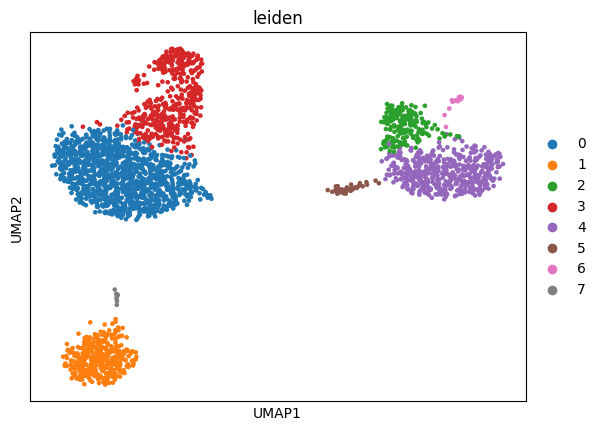

In [3]:
# Basic QC filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Log-normalize, keeping a "lognorm" layer for marker scoring and dotplots
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

# Highly variable genes, scale, PCA
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)

# Neighbors, Leiden clustering, UMAP
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)
sc.tl.umap(adata)

sc.pl.umap(adata, color="leiden")

## 2.3 Manual annotation

We look at the top marker genes per Leiden cluster with `sc.tl.rank_genes_groups`, then score each cluster against a small set of canonical PBMC marker genes and assign whichever cell type scores highest. Scoring clusters (rather than hardcoding "cluster 3 = X") is more robust to a different clustering resolution or a different run producing different cluster numbers.

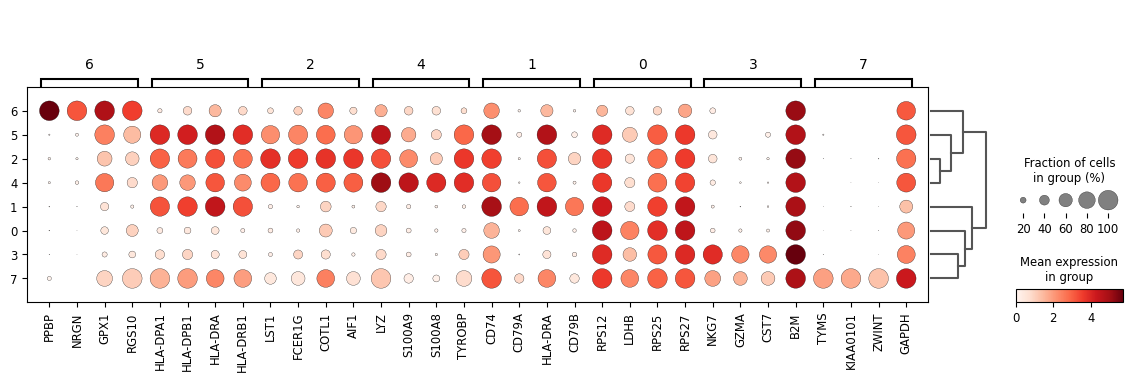

In [4]:
# Marker genes need to come from the full gene set (not just the 2000 HVGs we subset to),
# so we look them up from adata.raw
sc.tl.rank_genes_groups(adata, groupby="leiden", use_raw=True, method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4)

In [5]:
# Canonical PBMC marker genes for each expected cell type
pbmc_marker_genes = {
    "CD4 T cells": ["IL7R", "CD3D", "CD3E"],
    "CD8 T cells": ["CD8A", "CD8B", "CD3D"],
    "B cells": ["MS4A1", "CD79A", "CD79B"],
    "NK cells": ["GNLY", "NKG7", "KLRD1"],
    "CD14+ Monocytes": ["CD14", "LYZ", "S100A8"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Megakaryocytes": ["PPBP", "PF4"],
}

def assign_manual_celltypes(adata, marker_genes, groupby="leiden", use_raw=True, label="manual_cell_type"):
    """Score each cell type's marker genes per cell, average within each cluster,
    and assign each cluster the cell type with the highest average score."""
    for name, genes in marker_genes.items():
        genes_present = [g for g in genes if g in (adata.raw.var_names if use_raw else adata.var_names)]
        sc.tl.score_genes(adata, genes_present, score_name=f"score_{name}", use_raw=use_raw)

    score_cols = [f"score_{name}" for name in marker_genes]
    cluster_scores = adata.obs.groupby(groupby)[score_cols].mean()
    cluster_scores.columns = list(marker_genes.keys())
    best_type_per_cluster = cluster_scores.idxmax(axis=1)

    adata.obs[label] = adata.obs[groupby].map(best_type_per_cluster).astype("category")
    return cluster_scores

pbmc_cluster_scores = assign_manual_celltypes(adata, pbmc_marker_genes)
pbmc_cluster_scores.round(2)

,CD4 T cells,CD8 T cells,B cells,NK cells,CD14+ Monocytes,FCGR3A+ Monocytes,Dendritic cells,Megakaryocytes
leiden,,,,,,,,
0,0.71,0.11,-0.77,-0.40,-0.50,-0.22,-0.53,-0.04
1,-0.76,-0.71,1.70,-0.42,-0.49,-0.20,-0.50,-0.03
2,-1.33,-0.97,-0.73,-0.53,0.46,1.80,1.06,0.01
3,0.27,0.17,-0.78,1.57,-0.60,0.24,-0.53,-0.04
4,-1.16,-0.81,-0.84,-0.46,2.58,-0.00,1.19,0.01
5,-1.17,-0.98,-0.93,-0.53,0.82,-0.24,2.32,-0.03
6,-0.59,-0.64,-0.61,-0.23,0.12,-0.09,0.53,5.07
7,-0.66,-0.28,-0.73,0.19,-0.81,-0.37,-0.62,-0.09


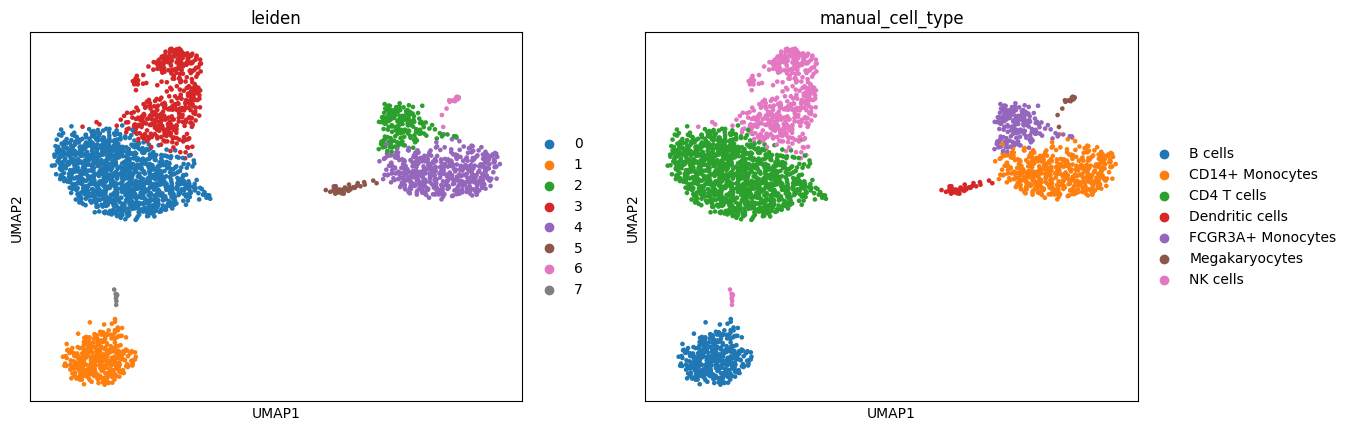

In [6]:
sc.pl.umap(adata, color=["leiden", "manual_cell_type"])

## 2.4 Automated annotation with CellTypist

CellTypist ships pretrained models and can optionally refine its per-cell predictions with `majority_voting`, which reassigns each cell the most common prediction within a Leiden over-clustering of its own. We use the `Immune_All_Low.pkl` model, trained across many immune cell subtypes.

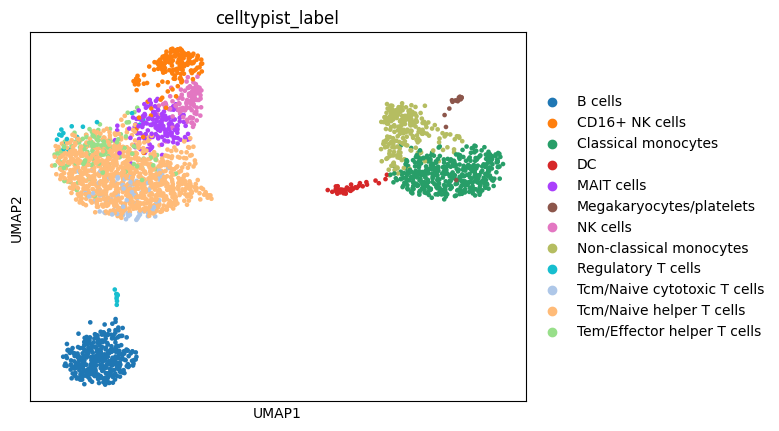

In [7]:
# Download the pretrained model (only needs to happen once per session)
models.download_models(model=["Immune_All_Low.pkl"])

# adata.raw was set right after log1p (before HVG subsetting/scaling), so raw.X is
# already the log-normalized, full-gene matrix CellTypist expects - no extra layer lookup needed
adata_for_celltypist = adata.raw.to_adata()

predictions = celltypist.annotate(adata_for_celltypist, model="Immune_All_Low.pkl", majority_voting=True)
adata.obs["celltypist_label"] = get_celltypist_labels(predictions).values

sc.pl.umap(adata, color="celltypist_label")

## 2.5 Compare manual vs. automated annotation

In [8]:
pd.crosstab(adata.obs["manual_cell_type"], adata.obs["celltypist_label"])

celltypist_label,B cells,CD16+ NK cells,Classical monocytes,DC,MAIT cells,Megakaryocytes/platelets,NK cells,Non-classical monocytes,Regulatory T cells,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells
manual_cell_type,,,,,,,,,,,,
B cells,349,0,0,0,0,0,0,0,0,0,0,0
CD14+ Monocytes,0,0,422,2,0,1,0,49,0,0,0,0
CD4 T cells,0,1,0,0,15,0,0,0,11,76,958,124
Dendritic cells,0,0,0,36,0,0,0,0,0,0,0,0
FCGR3A+ Monocytes,0,0,1,0,0,0,0,175,0,0,0,0
Megakaryocytes,0,0,0,0,0,15,0,0,0,0,0,0
NK cells,0,171,0,0,145,0,106,0,13,0,24,6


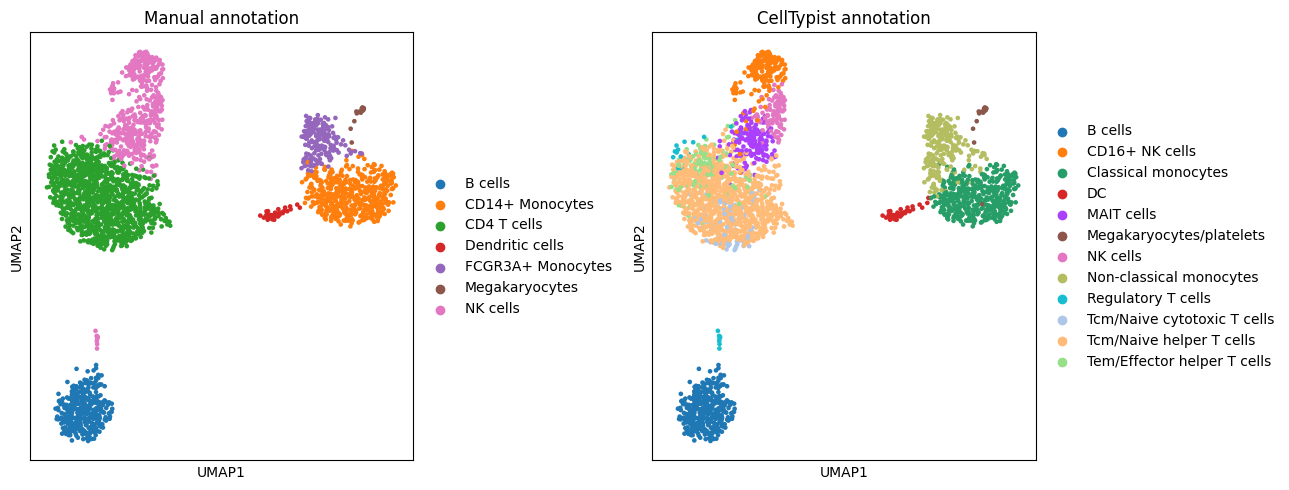

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata, color="manual_cell_type", ax=axes[0], show=False, title="Manual annotation")
sc.pl.umap(adata, color="celltypist_label", ax=axes[1], show=False, title="CellTypist annotation")
plt.tight_layout()

A mismatch between the two isn't automatically a mistake in either direction: it could mean the manual marker set was too coarse (e.g. lumping two closely related T cell subtypes together), or that CellTypist's reference doesn't cleanly separate a population present in this particular sample. When the two disagree, it's worth looking at the actual marker gene expression for the disputed cells before trusting either label.

# **3. Part B: Visium cell type annotation**

We repeat the same manual + automated recipe from Part A on Visium spot data, using the public 10x **human lymph node** Visium sample which pairs with the same CellTypist immune model used above.

**Important caveat for spot-based data:** each Visium spot typically captures several to a few dozen cells. A "cell type" label assigned to a spot is really a *dominant type* call for a mixture of cells, not a single-cell truth. If you need to resolve the actual mixture of cell types within each spot, look into deconvolution methods (e.g. cell2location, RCTD, stereoscope).

## 3.1 Load data

In [10]:
adata_vis = sq.datasets.visium("V1_Human_Lymph_Node")
adata_vis.var_names_make_unique()
adata_vis

  0%|          | 0.00/7.86M [00:00<?, ?B/s]

  0%|          | 0.00/29.3M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

**Using your own data:** replace the cell above with `sc.read_visium("path/to/spaceranger_outs/")` (or `spatialdata_io.visium()` for a full `SpatialData` object).

## 3.2 Preprocessing and clustering

Same steps as section 2.2 (QC filter, normalize/log1p, HVG, scale, PCA, neighbors, Leiden, UMAP), condensed into one cell here.

In [11]:
sc.pp.calculate_qc_metrics(adata_vis, inplace=True, percent_top=None)
sc.pp.filter_cells(adata_vis, min_counts=500)
sc.pp.filter_genes(adata_vis, min_cells=10)

sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
adata_vis.layers["lognorm"] = adata_vis.X.copy()

sc.pp.highly_variable_genes(adata_vis, n_top_genes=2000)
adata_vis.raw = adata_vis
adata_vis = adata_vis[:, adata_vis.var.highly_variable].copy()
sc.pp.scale(adata_vis, max_value=10)
sc.tl.pca(adata_vis, n_comps=30)

sc.pp.neighbors(adata_vis)
sc.tl.leiden(adata_vis, flavor="igraph", n_iterations=-1, resolution=0.5)

## 3.3 Manual annotation

In [12]:
lymph_node_marker_genes = {
    "T cell zone": ["CD3D", "CD3E", "CD2"],
    "B cell follicle": ["MS4A1", "CD79A", "CD19"],
    "Germinal center": ["MKI67", "AICDA", "BCL6"],
    "Plasma cells": ["MZB1", "IGHG1", "JCHAIN"],
    "Macrophages": ["CD68", "CD163"],
    "Follicular dendritic cells": ["CR2", "FDCSP"],
    "Endothelial": ["PECAM1", "VWF"],
}

lymph_node_cluster_scores = assign_manual_celltypes(adata_vis, lymph_node_marker_genes)
lymph_node_cluster_scores.round(2)

,T cell zone,B cell follicle,Germinal center,Plasma cells,Macrophages,Follicular dendritic cells,Endothelial
leiden,,,,,,,
0,-0.09,0.07,0.00,1.53,0.03,-0.20,0.22
1,0.29,-0.23,-0.02,0.80,0.01,-0.21,-0.06
2,-0.18,0.18,-0.01,0.95,0.12,0.12,0.17
3,-0.13,0.16,0.03,1.13,0.07,0.31,0.18
4,0.13,-0.19,0.07,0.69,0.04,0.11,-0.16
5,-0.13,0.45,0.03,0.63,-0.05,0.73,-0.14
6,-0.21,0.36,0.43,0.71,0.00,1.20,-0.24


## 3.4 Automated annotation with CellTypist

In [13]:
# adata_vis.raw.X is already log-normalized (same reasoning as section 2.4)
adata_vis_for_celltypist = adata_vis.raw.to_adata()

vis_predictions = celltypist.annotate(adata_vis_for_celltypist, model="Immune_All_Low.pkl", majority_voting=True)
adata_vis.obs["celltypist_label"] = get_celltypist_labels(vis_predictions).values

## 3.5 Compare spatially

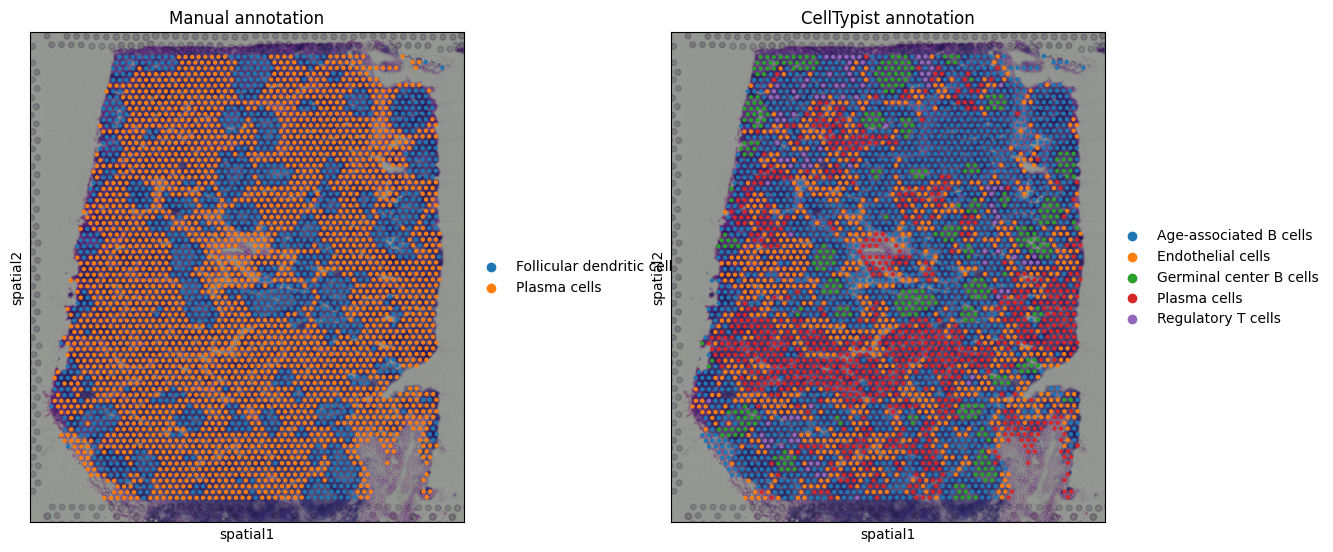

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sc.pl.spatial(adata_vis, color="manual_cell_type", ax=axes[0], show=False, title="Manual annotation")
sc.pl.spatial(adata_vis, color="celltypist_label", ax=axes[1], show=False, title="CellTypist annotation")
plt.tight_layout()

In [15]:
del adata_vis, adata_vis_for_celltypist
gc.collect()

774

# **4. Part C: Xenium cell type annotation**

## 4.1 Load data

Due to Colab memory alocations, not all full sample sizes can be used. Instead we reuse the **cropped sub-region** from the full 10x breast cancer Xenium sample as (`cropped_sdata_v2.zarr`): a much smaller subset of the same tissue, with the same precomputed Leiden clusters, so everything below still applies unchanged.

In [16]:
# this step will take ~1 min
!wget -nc https://cf.10xgenomics.com/supp/xenium/analysis-workshop/cropped_sdata_v2.zarr.zip
!unzip -n cropped_sdata_v2.zarr.zip

sd_data = sd.read_zarr("cropped_sdata_v2.zarr")
adata_xen = sd_data["table"]
adata_xen

--2026-09-29 07:59:05--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/cropped_sdata_v2.zarr.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 409653268 (391M) [application/zip]
Saving to: ‘cropped_sdata_v2.zarr.zip’

cropped_sdata_v2.za 100%[===================>] 390.68M   212MB/s    in 1.8s    

2026-09-29 07:59:07 (212 MB/s) - ‘cropped_sdata_v2.zarr.zip’ saved [409653268/409653268]

Archive:  cropped_sdata_v2.zarr.zip
   creating: cropped_sdata_v2.zarr/
 extracting: cropped_sdata_v2.zarr/zmetadata  
   creating: cropped_sdata_v2.zarr/tables/
   creating: cropped_sdata_v2.zarr/tables/table/
   creating: cropped_sdata_v2.zarr/tables/table/obs/
   creating: cropped_sdata_v2.zarr/tables/table/obs/_index/
 extracting: cropped_sdata_v2.zarr/tables/table/obs/_index/0  
 extracting:

AnnData object with n_obs × n_vars = 36923 × 5085
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_counts', 'leiden', 'manual_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'manual_cell_type_nhood_enrichment', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

## 4.2 Manual annotation

Not every cluster will necessarily still have cells in this smaller sub-region that's expected due to cropping.

In [17]:
manual_labels_by_cluster = {
    "0": "Tumor1", "1": "Tumor2", "2": "Adipocytes", "3": "Smooth Muscle Cells",
    "4": "Macrophages", "5": "Tumor3", "6": "Endothelial", "7": "Fibroblasts",
    "8": "T Cells", "9": "B Cells", "10": "DCs", "11": "Plasma Cells",
    "12": "pDCs", "13": "Mast Cells",
}
adata_xen.obs["manual_cell_type"] = adata_xen.obs["leiden"].map(manual_labels_by_cluster).astype("category")

## 4.3 Automated annotation with CellTypist

Xenium's targeted gene panel (a curated ~5,000-gene panel, not whole-transcriptome) does not fully overlap with the genes a general-purpose classifier like `Immune_All_Low.pkl` was trained on, and this tissue also contains many non-immune populations (tumor, adipocytes, fibroblasts, smooth muscle) that an *immune* model was never trained to recognize in the first place. We run it anyway to make the mismatch concrete: expect immune clusters (T/B/Plasma/DC/Mast cells) to come back reasonably labeled, and non-immune populations to come back as low-confidence or "Unassigned" calls. Before trusting an automated call on a targeted spatial panel, check (a) how many of the model's marker genes are actually present in your panel, and (b) the model's per-cell confidence scores, not just the label.

In [18]:
adata_xen_for_celltypist = adata_xen.copy()
adata_xen_for_celltypist.X = adata_xen_for_celltypist.layers["lognorm"]

xen_predictions = celltypist.annotate(adata_xen_for_celltypist, model="Immune_All_Low.pkl", majority_voting=True)
adata_xen.obs["celltypist_label"] = get_celltypist_labels(xen_predictions).values

pd.crosstab(adata_xen.obs["manual_cell_type"], adata_xen.obs["celltypist_label"])

celltypist_label,Alveolar macrophages,B cells,CD16+ NK cells,Classical monocytes,Double-negative thymocytes,Endothelial cells,Epithelial cells,Fibroblasts,HSC/MPP,ILC,...,Memory B cells,Myelocytes,Naive B cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Trm cytotoxic T cells,Trm cytotoxic T cells,Type 17 helper T cells,pDC
manual_cell_type,,,,,,,,,,,,,,,,,,,,,
Tumor1,2,0,0,21,0,0,41,2,0,0,...,0,0,0,0,9581,0,0,0,0,0
Tumor2,0,0,0,4,0,0,17,0,0,0,...,0,0,0,0,360,0,0,0,0,0
Adipocytes,1,0,0,8,0,1,9,2,0,0,...,0,0,0,0,415,0,1,0,0,0
Smooth Muscle Cells,1,0,0,1,0,0,8,0,2,0,...,0,0,0,0,63,0,0,0,0,0
Macrophages,13,0,0,25,0,2,23,2,0,0,...,0,1,0,0,5360,0,0,0,1,0
Tumor3,0,0,0,6,0,0,4,0,0,0,...,0,0,0,0,1879,0,0,0,0,0
Endothelial,9,2,0,27,1,106,29,4,0,0,...,1,1,0,0,2271,0,0,0,0,0
Fibroblasts,5,1,0,44,1,3,36,33,0,0,...,2,2,1,0,3018,1,0,0,0,0
T Cells,25,3,1,129,0,2,71,7,0,1,...,4,2,0,1,7655,0,19,1,0,0


## 4.4 Compare spatially

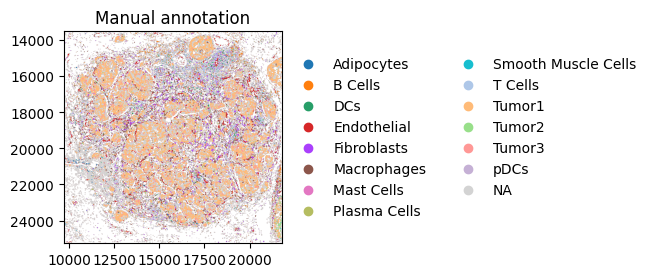

In [19]:
sd_data.tables["table"].obs["region"] = "cell_boundaries"
sd_data.set_table_annotates_spatialelement("table", region="cell_boundaries")

sd_data.pl.render_shapes("cell_boundaries", color="manual_cell_type", method="datashader").pl.show(title="Manual annotation")

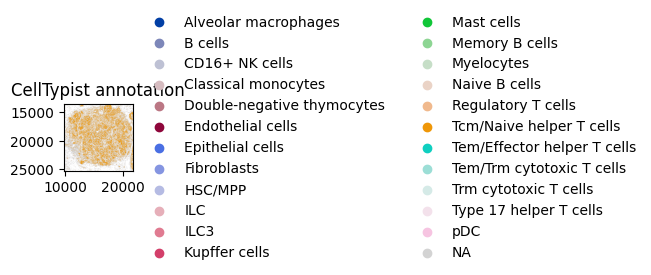

In [20]:
sd_data.pl.render_shapes("cell_boundaries", color="celltypist_label", method="datashader").pl.show(title="CellTypist annotation")

# **5. Part D: Importing GeoJSON annotations into spatial data**

## 5.1 Background: pathology annotations as GeoJSON

Pathologists commonly draw regions of interest (tumor, necrosis, stroma, specific ducts, etc.) on the same tissue image in tools like [QuPath](https://qupath.readthedocs.io/), then export them via **File -> Object data -> Export as GeoJSON**. A GeoJSON export is a `FeatureCollection` of polygons, where each feature's `properties` typically include a `classification` (the pathologist's region label, e.g. `{"name": "Tumor", "color": [255, 0, 0]}`).

Two things to check before trusting a real pathology GeoJSON import:

1. **Coordinate system.** QuPath annotation coordinates are in *image pixel coordinates* of whatever image you had open. These must line up with the coordinate system your transcript/cell coordinates are stored in. If the pathology image and the SpatialData object's image were captured or downsampled at different resolutions, you will need to rescale the polygon coordinates (`spatialdata.transformations.Scale`/`Affine`) before they will overlay correctly.
2. **Axis orientation.** Image coordinate systems sometimes have the y-axis flipped relative to stage/transcript coordinates. If your imported polygons land upside-down relative to the cells, this is the first thing to check.

## 5.2 What this section actually uses (and why)

**This section does not use a real pathologist annotation.** This is an example of how to use a GeoJSON with spatial data. Other methods to obtain coordinates work including using coordinates selected using Xenium Browser or Loupe Browser. Tutorials for these can be found online from 10x. This is just a demonstration of the usability of selecting specific regions.

Xenium Explorer will export as a CSV of vertex coordinates rather than GeoJSON directly - converting between annotation export formats like this is itself a  common step, since different tools (Explorer, QuPath, Loupe Browser) don't all export the same format.

*This can be modified with your own selection from Xenium Explorer using a similar idea.*

In [21]:
!wget -nc https://cf.10xgenomics.com/supp/xenium/analysis-workshop/Selection_1_coordinates.csv

# spatialdata_io parses a Xenium Explorer coordinate-selection export directly into a Shapely polygon
tumor_region_polygon = sio.xenium_explorer_selection("Selection_1_coordinates.csv")

# Our Part C sample was itself cropped to exactly this selection, so used as-is it would
# cover ~all cells here and show no contrast. Shrink it around its own centroid so it only
# covers part of the cropped tissue - purely so the demo below has an inside/outside split
# to show, not a claim about the true extent of the underlying selection.
tumor_region_polygon = shapely_affinity.scale(tumor_region_polygon, xfact=0.6, yfact=0.6, origin="centroid")

# Wrap it as a GeoJSON FeatureCollection, the same shape a QuPath export would take
tumor_polygon = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"classification": {"name": "Selected Region"}},
            "geometry": sgeom.mapping(tumor_region_polygon),
        },
    ],
}

with open("pathology_regions.geojson", "w") as f:
    json.dump(tumor_polygon, f)

# "cell_boundaries" as stored on disk is in its OWN local coordinates plus a registered
# transformation to "global" - render_shapes() applies that transform automatically, but
# reading .geometry directly (as we do below) does NOT. tumor_region_polygon is in "global"
# space (that is what target_coordinate_system="global" meant when it was used to crop this
# sample originally), so we must resolve cell_boundaries into "global" the same way before
# comparing coordinates, or the two will not line up despite both being "correct".
cell_boundaries_global = sd.transform(sd_data.shapes["cell_boundaries"], to_coordinate_system="global")
cell_coords = cell_boundaries_global.geometry.centroid

--2026-09-29 07:59:33--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/Selection_1_coordinates.csv
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 249 [text/csv]
Saving to: ‘Selection_1_coordinates.csv’

Selection_1_coordin 100%[===================>]     249  --.-KB/s    in 0s      

2026-09-29 07:59:34 (116 MB/s) - ‘Selection_1_coordinates.csv’ saved [249/249]



## 5.3 Load the GeoJSON into the SpatialData object

In [22]:
# Store it on the SpatialData object as a proper Shapes element, the way you would keep it
# around for later use. We still register a "global" transformation so this stored copy is
# usable elsewhere in the object - but for the join/plot below we use the original in-memory
# polygon directly (see 5.4), to keep this demo independent of any transform-handling detail.
pathology_shapes = ShapesModel.parse("pathology_regions.geojson", transformations={"global": Identity()})
sd_data.shapes["pathology_regions"] = pathology_shapes
sd_data.shapes["pathology_regions"]

,geometry
0,"POLYGON ((12174.019 15898.09, 19299.366 15898...."


## 5.4 Assign each cell a pathology region label

We join cell centroids against the pathology polygons with a spatial (point-in-polygon) join, then add the result as a new `.obs` column.

In [23]:
cells_gdf = gpd.GeoDataFrame(geometry=cell_coords, index=cell_coords.index)

# Use the in-memory polygon directly (not a round-trip through sd_data.shapes) so there is
# no room for a transformation/registration step to silently shift these coordinates -
# this is the exact same polygon object the source workshop notebook used to crop this sample
region_names = [f["properties"]["classification"]["name"] for f in tumor_polygon["features"]]
regions_gdf = gpd.GeoDataFrame({"classification": region_names}, geometry=[tumor_region_polygon])

joined = gpd.sjoin(cells_gdf, regions_gdf[["geometry"]], how="left", predicate="within")
# A cell exactly on a shared edge between two adjacent polygons (or inside two overlapping
# real pathology annotations) can match more than one region; keep just the first match per cell
joined = joined[~joined.index.duplicated(keep="first")]

index_to_name = dict(zip(regions_gdf.index, region_names))
pathology_by_shape_id = joined["index_right"].map(index_to_name).fillna("Unassigned")

# adata_xen.obs_names is not guaranteed to equal the "cell_boundaries" shapes index -
# spatialdata records the actual table<->shapes correspondence as the "instance_key"
# column in .obs, so we join through that column rather than assuming index equality
instance_key = sd_data.tables["table"].uns["spatialdata_attrs"]["instance_key"]
adata_xen.obs["pathology_region"] = adata_xen.obs[instance_key].map(pathology_by_shape_id).values

adata_xen.obs["pathology_region"].value_counts()

,count
pathology_region,
Unassigned,20413
Selected Region,16510


## 5.5 Visualize and cross-tabulate

Dropping 13173 segmented shapes with no matching table row


Text(0.5, 1.0, 'Cell type annotation overlaid with pathology regions')

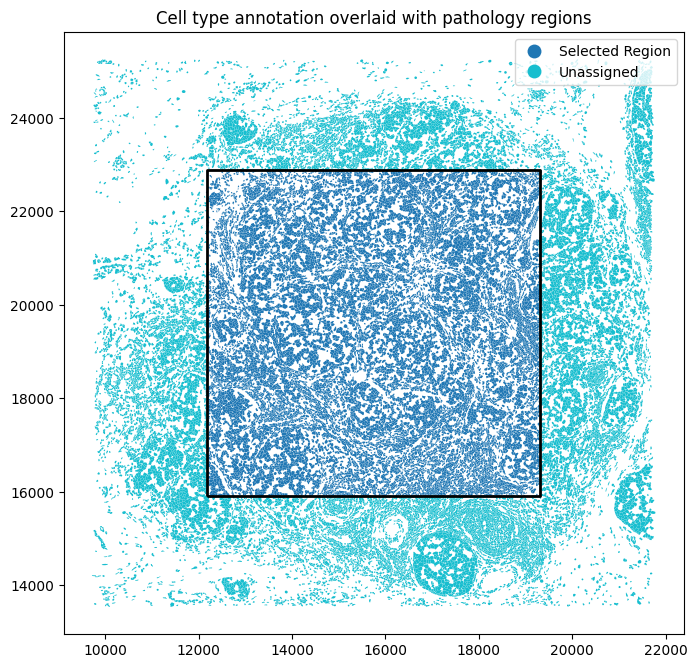

In [24]:
# Plot both layers with plain GeoPandas/Matplotlib on one shared axis, in "global" coordinates.
# Reuse cell_boundaries_global from 5.2 (already resolved to "global" via sd.transform) rather
# than the raw sd_data.shapes["cell_boundaries"], which is in its own untransformed local space.
cell_boundaries_gdf = cell_boundaries_global.copy()
id_to_region = adata_xen.obs.set_index(instance_key)["pathology_region"]
cell_boundaries_gdf["pathology_region"] = cell_boundaries_gdf.index.map(id_to_region)

# "cell_boundaries" can contain segmented objects that were filtered out of the table
# during earlier QC (they have no cell type/pathology label to show), so drop those here
n_unmatched = int(cell_boundaries_gdf["pathology_region"].isna().sum())
if n_unmatched:
    print(f"Dropping {n_unmatched} segmented shapes with no matching table row")
cell_boundaries_gdf = cell_boundaries_gdf[cell_boundaries_gdf["pathology_region"].notna()]

fig, ax = plt.subplots(figsize=(8, 8))
cell_boundaries_gdf.plot(column="pathology_region", categorical=True, legend=True, ax=ax, linewidth=0)
regions_gdf.boundary.plot(ax=ax, color="black", linewidth=2)
ax.set_aspect("equal")
ax.set_title("Cell type annotation overlaid with pathology regions")

In [25]:
pd.crosstab(adata_xen.obs["manual_cell_type"], adata_xen.obs["pathology_region"])

pathology_region,Selected Region,Unassigned
manual_cell_type,,
Tumor1,5450,4197
Tumor2,183,199
Adipocytes,99,339
Smooth Muscle Cells,28,47
Macrophages,2529,2898
Tumor3,1086,803
Endothelial,1061,1391
Fibroblasts,1485,1662
T Cells,2831,5090


If a real pathology GeoJSON's polygons don't line up with the cells the way this stand-in region does - everything lands as `"Unassigned"`, or the regions are visibly offset or mirrored from the tissue - that is almost always the coordinate-system or axis-orientation issue described in 5.1.

# **6. Wrap-up**

Manual annotation (marker genes -> cluster -> label) is transparent and easy to check, but slow and dependent on the analyst's domain knowledge. Automated annotation (CellTypist here, or scMRMA, SingleR, and others more generally) scales to many samples and is more reproducible, but is only as good as the fit between its reference and your actual tissue, technology, and gene panel - a mismatch is most visible exactly where we saw it in Part C, applying an immune-focused classifier to a tumor sample with a targeted gene panel. Bringing in an externally drawn region (a pathologist's QuPath export, an Explorer/Loupe selection, or any other ROI tool) via GeoJSON turns that outside assessment into a first-class label you can directly cross-tabulate against either kind of cell type annotation.

For further reading: [CellTypist documentation](https://www.celltypist.org/), the [scMRMA paper](https://academic.oup.com/nar/article/50/2/e7/6396893), and [QuPath's annotation export documentation](https://qupath.readthedocs.io/en/stable/docs/advanced/exporting_annotations.html).